# перед запуском в data/raw нужно положить csv файлы с кагла



**иточник:** [Kaggle — Uber & Lyft Dataset Boston, MA](https://www.kaggle.com/datasets/brllrb/uber-and-lyft-dataset-boston-ma)

**как нашёл:** искал задачу с прогнозированием чего-нибудь интересного, прогнозирование с самолётами было занято, решил вязть прогноз цены на такси

- Реальные данные о поездках двух конкурентов (Uber и Lyft) в одном городе — позволяет исследовать **динамическое ценообразование**
- Датасет содержит дополнительный файл с погодой, что даёт возможность строить **мультимодальные признаки**
- чёткая регрессионная задача: предсказать **цену поездки** (`price`) — практически применимый кейс

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

rides   = pd.read_csv("data/raw/cab_rides.csv")
weather = pd.read_csv("data/raw/weather.csv")

print("cab_rides.csv")
print(f"строк:   {rides.shape[0]:,}")
print(f"столбцов: {rides.shape[1]}")
print(rides.dtypes.to_string())


cab_rides.csv
строк:   693,071
столбцов: 10
distance            float64
cab_type                str
time_stamp            int64
destination             str
source                  str
price               float64
surge_multiplier    float64
id                      str
product_id              str
name                    str


In [2]:
rides.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [3]:
print(" weather.csv")
print(f"строк:   {weather.shape[0]:,}")
print(f"сьолбцов: {weather.shape[1]}")
print()
print(weather.dtypes.to_string())
print()

 weather.csv
строк:   6,276
сьолбцов: 8

temp          float64
location          str
clouds        float64
pressure      float64
rain          float64
time_stamp      int64
humidity      float64
wind          float64



In [4]:
weather.head(3)

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.0,1012.14,0.1228,1545003901,0.77,11.25
1,42.43,Beacon Hill,1.0,1012.15,0.1846,1545003901,0.76,11.32
2,42.50,Boston University,1.0,1012.15,0.1089,1545003901,0.76,11.07


In [5]:
print("статистика по числовым столбцам (cab_rides):")
rides.describe().round(2)

статистика по числовым столбцам (cab_rides):


,distance,time_stamp,price,surge_multiplier
count,693071.00,6.930710e+05,637976.00,693071.00
mean,2.19,1.544046e+12,16.55,1.01
std,1.14,6.891925e+08,9.32,0.09
min,0.02,1.543204e+12,2.50,1.00
25%,1.28,1.543444e+12,9.00,1.00
50%,2.16,1.543737e+12,13.50,1.00
75%,2.92,1.544828e+12,22.50,1.00
max,7.86,1.545161e+12,97.50,3.00


**описание столбцов cab_rides.csv:**

| столбец | тип | описание |
|---|---|---|
| `distance` | float | Расстояние поездки (мили) |
| `cab_type` | object | Компания: Uber / Lyft |
| `time_stamp` | int64 | Unix-время в миллисекундах |
| `destination` | object | Точка назначения |
| `source` | object | Точка отправления |
| `price` | float | **Целевая переменная** — цена ($) |
| `surge_multiplier` | float | Коэффициент спроса (1.0 = нет надбавки) |
| `id` | object | Уникальный ID поездки |
| `product_id` | object | ID тарифа |
| `name` | object | Название тарифа (UberX, Lyft XL и т.д.) |

---
## объединение 

In [6]:
rides['date_time']   = pd.to_datetime(rides['time_stamp'],   unit='ms')
weather['date_time'] = pd.to_datetime(weather['time_stamp'], unit='s')

for df_temp in [rides, weather]:
    df_temp['hour']  = df_temp['date_time'].dt.hour
    df_temp['day']   = df_temp['date_time'].dt.day
    df_temp['month'] = df_temp['date_time'].dt.month

weather_avg = (
    weather
    .groupby(['location', 'month', 'day', 'hour'])
    .mean(numeric_only=True)
    .reset_index()
)

df = pd.merge(
    rides, weather_avg,
    left_on=['source', 'month', 'day', 'hour'],
    right_on=['location', 'month', 'day', 'hour'],
    how='left'
)


In [7]:
print(f"после объединения: {df.shape[0]:,} строк, {df.shape[1]} столбцов")

после объединения: 693,071 строк, 22 столбцов


---
## очистка данных

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'пропусков': missing, '% от всего': missing_pct})
print("пропуски до очистки:")
print(missing_df[missing_df['пропусков'] > 0].to_string())

пропуски до очистки:
              пропусков  % от всего
price             55095        7.95
location           2964        0.43
temp               2964        0.43
clouds             2964        0.43
pressure           2964        0.43
rain             574394       82.88
time_stamp_y       2964        0.43
humidity           2964        0.43
wind               2964        0.43


# типизация

In [9]:
cat_cols = ['cab_type', 'destination', 'source', 'name']
for col in cat_cols:
    df[col] = df[col].astype('category')

print("типы после приведения:")
print(df[cat_cols].dtypes)

типы после приведения:
cab_type       category
destination    category
source         category
name           category
dtype: object


# обработка дубликатов

In [10]:
n_before = len(df)
df = df.drop_duplicates()
print(f"дубликатов удалено: {n_before - len(df):,}")
print(f"строк после: {len(df):,}")

дубликатов удалено: 0
строк после: 693,071


In [11]:
n_before = len(df)
df = df.dropna(subset=['price'])
print(f"строк без цены удалено: {n_before - len(df):,}")

# NaN - 0
df['rain'] = df['rain'].fillna(0)

weather_cols = ['temp', 'clouds', 'pressure', 'humidity', 'wind']
for col in weather_cols:
    df[col] = df[col].fillna(df[col].median())

df['location']     = df['location'].fillna(df['source'])
df['time_stamp_y'] = df['time_stamp_y'].fillna(df['time_stamp_x'] / 1000)

print("\nпропуски после заполнения:")
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining.any() else "пропусков нет")

строк без цены удалено: 55,095

пропуски после заполнения:
пропусков нет


price: удалено 11,343 выбросов (за пределами 1%-99% перцентилей)
distance: удалено 12,260 выбросов (за пределами 1%-99% перцентилей)


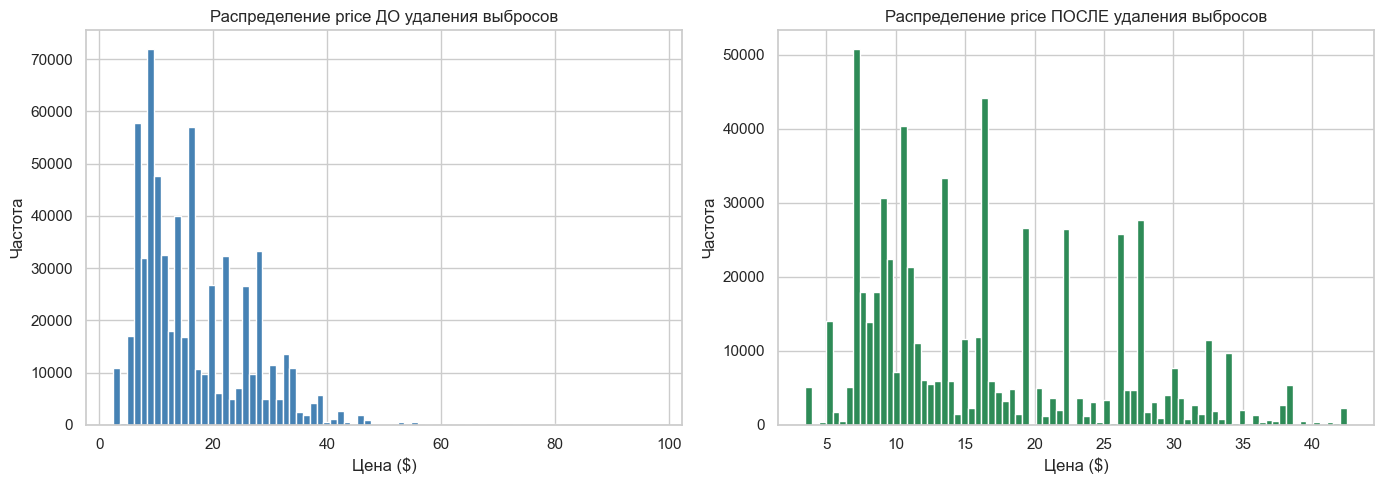


Итого строк после очистки: 614,373


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].set_title('Распределение price ДО удаления выбросов')
axes[0].hist(df['price'].dropna(), bins=80, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Цена ($)')
axes[0].set_ylabel('Частота')

for col in ['price', 'distance']:
    Q1 = df[col].quantile(0.01)
    Q3 = df[col].quantile(0.99)
    before = len(df)
    df = df[(df[col] >= Q1) & (df[col] <= Q3)]
    print(f"{col}: удалено {before - len(df):,} выбросов (за пределами 1%-99% перцентилей)")

df = df[df['distance'] > 0]

axes[1].set_title('Распределение price ПОСЛЕ удаления выбросов')
axes[1].hist(df['price'].dropna(), bins=80, color='seagreen', edgecolor='white')
axes[1].set_xlabel('Цена ($)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.savefig('data/processed/price_outliers.png', dpi=150)
plt.show()

print(f"\nИтого строк после очистки: {len(df):,}")

---
## Feature Engineering

**Исходное количество признаков (после join и очистки):**

In [13]:
df = df.drop(columns=['time_stamp_x', 'id', 'date_time', 'product_id'], errors='ignore')

original_features = [c for c in df.columns if c != 'price']
print(f"исходных признаков: {len(original_features)}")
print(original_features)

исходных признаков: 17
['distance', 'cab_type', 'destination', 'source', 'surge_multiplier', 'name', 'hour', 'day', 'month', 'location', 'temp', 'clouds', 'pressure', 'rain', 'time_stamp_y', 'humidity', 'wind']


In [14]:
# день недели (0=Пн ... 6=Вс)
df['day_of_week'] = pd.to_datetime(df['time_stamp_y'], unit='s').dt.weekday

# выходной день
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# плохая погода: дождь ИЛИ температура ниже нуля по Фаренгейту (32°F = 0°C)
df['bad_weather'] = ((df['rain'] > 0) | (df['temp'] < 32)).astype(int)

# уникальный маршрут
df['route'] = df['source'].astype(str) + " -> " + df['destination'].astype(str)

# класс (Luxury vs Economy)
luxury_types = ['Black SUV', 'Black', 'Lux Black XL', 'Lux Black']
df['is_luxury'] = df['name'].isin(luxury_types).astype(int)

def time_of_day(h):
    if 6  <= h < 10: return 'morning_rush'
    if 10 <= h < 16: return 'midday'
    if 16 <= h < 20: return 'evening_rush'
    return 'night'

df['time_segment'] = df['hour'].apply(time_of_day)

new_features = ['day_of_week', 'is_weekend', 'bad_weather', 'route', 'is_luxury', 'time_segment']
print(f"добавлено новых признаков: {len(new_features)}")
print(f"итоговых признаков (без таргета): {len([c for c in df.columns if c != 'price'])}")

print("\nописание новых признаков:")
desc = {
    'day_of_week':   'День недели (0=Пн, 6=Вс) — спрос меняется по дням',
    'is_weekend':    'Выходной? (0/1) — суррогатный признак пиковой нагрузки',
    'bad_weather':   'Плохая погода? (0/1) — дождь или мороз повышают спрос',
    'route':         'Маршрут source-dest — некоторые маршруты системно дороже',
    'is_luxury':     'Luxury-класс? (0/1) — грубый флаг ценового сегмента',
    'time_segment':  'Сегмент суток (morning_rush / midday / evening_rush / night)',
}
for k, v in desc.items():
    print(f"  {k:15s}: {v}")

добавлено новых признаков: 6
итоговых признаков (без таргета): 23

описание новых признаков:
  day_of_week    : День недели (0=Пн, 6=Вс) — спрос меняется по дням
  is_weekend     : Выходной? (0/1) — суррогатный признак пиковой нагрузки
  bad_weather    : Плохая погода? (0/1) — дождь или мороз повышают спрос
  route          : Маршрут source-dest — некоторые маршруты системно дороже
  is_luxury      : Luxury-класс? (0/1) — грубый флаг ценового сегмента
  time_segment   : Сегмент суток (morning_rush / midday / evening_rush / night)


---
## графики

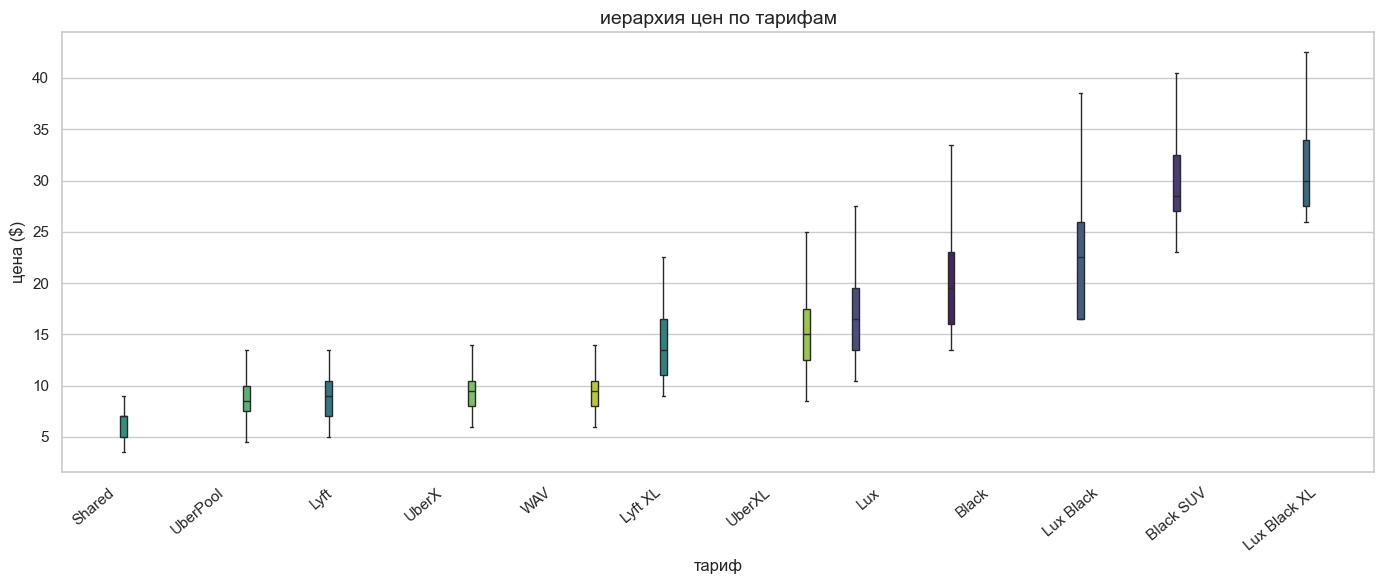

In [15]:
plt.figure(figsize=(14, 6))
order = df.groupby('name', observed=True)['price'].median().sort_values().index
sns.boxplot(x='name', y='price', data=df, order=order, hue='name',
            palette='viridis', legend=False, showfliers=False)
plt.title('иерархия цен по тарифам', fontsize=14)
plt.xlabel('тариф')
plt.ylabel('цена ($)')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('data/processed/boxplot_prices.png', dpi=150)
plt.show()

# цена от расстояния

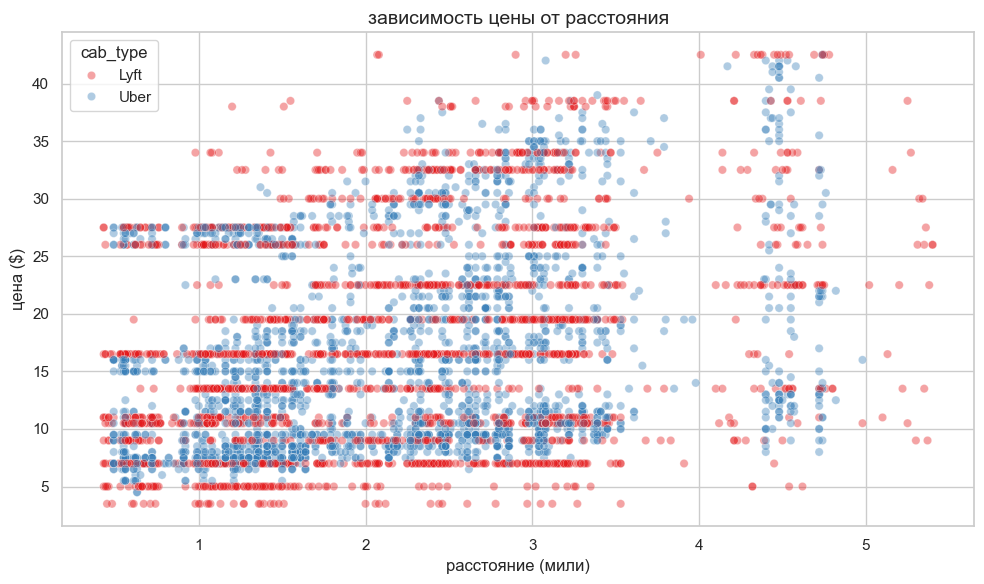

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance', y='price', hue='cab_type',
                data=df.sample(5000, random_state=42),
                alpha=0.4, palette='Set1')
plt.title('зависимость цены от расстояния', fontsize=14)
plt.xlabel('расстояние (мили)')
plt.ylabel('цена ($)')
plt.tight_layout()
plt.savefig('data/processed/scatter_distance.png', dpi=150)
plt.show()

# матрица корелляции

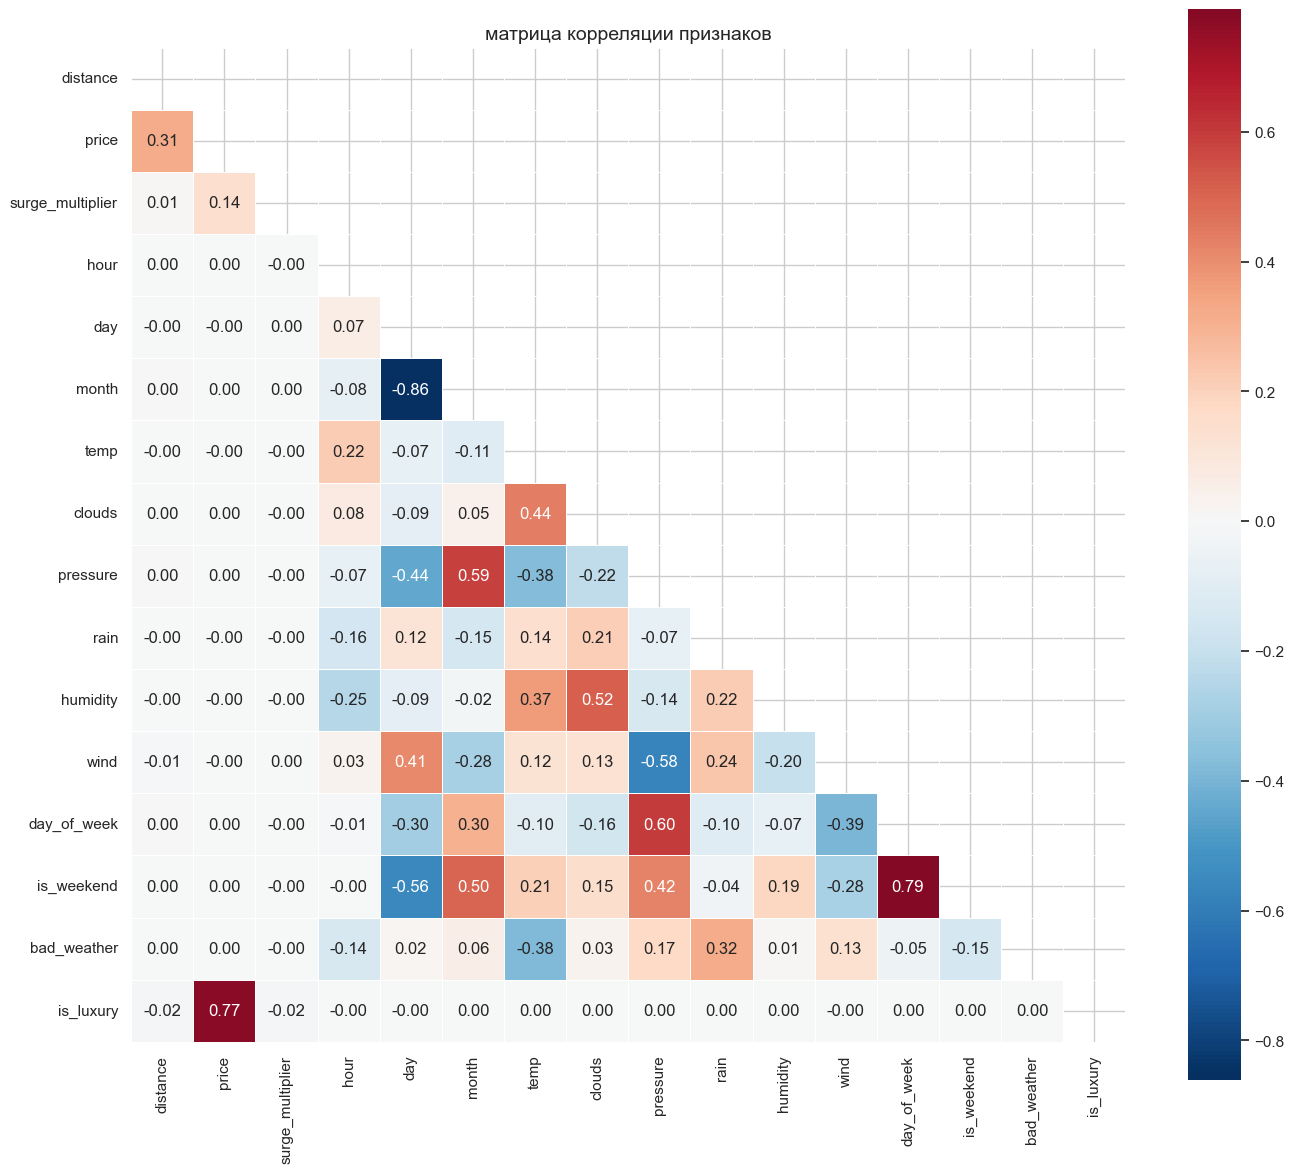

In [17]:
plt.figure(figsize=(14, 12))
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['time_stamp_y'], errors='ignore')
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=0.5)
plt.title('матрица корреляции признаков', fontsize=14)
plt.tight_layout()
plt.savefig('data/processed/correlation_matrix.png', dpi=150)
plt.show()

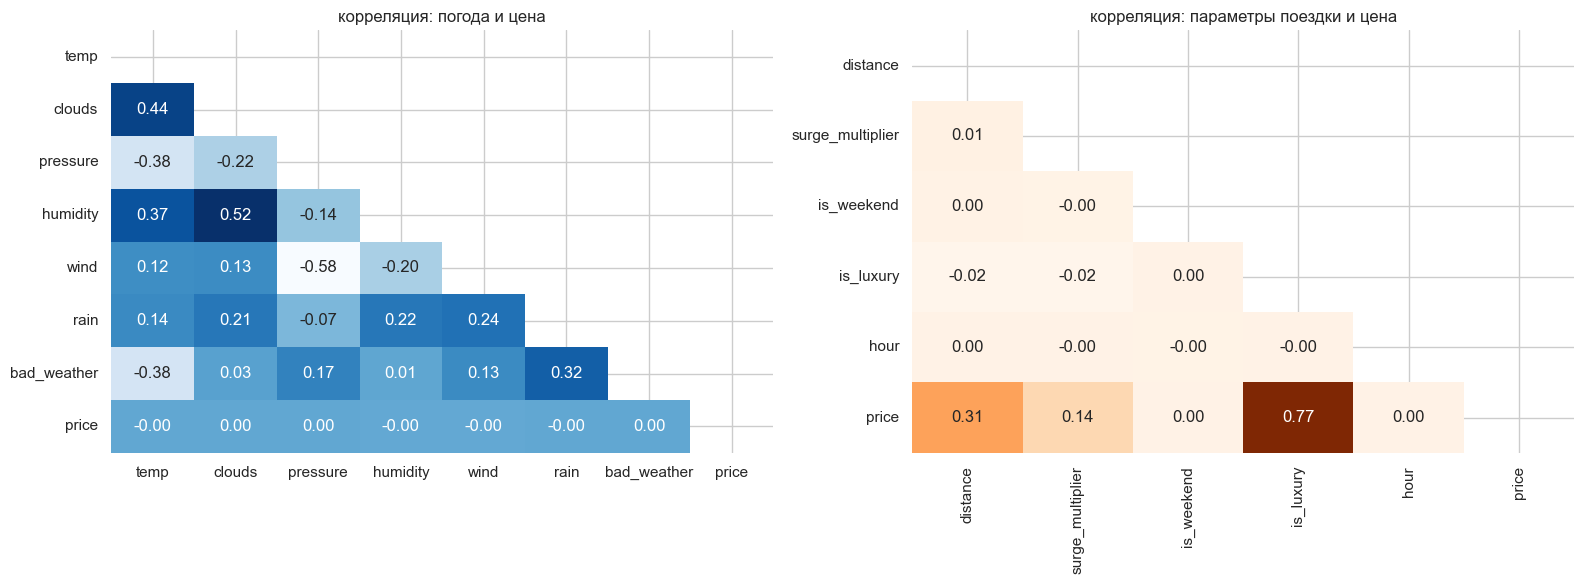

In [18]:
cols_to_corr = df.select_dtypes(include=[np.number]).columns.tolist()
if 'price_per_mile' in cols_to_corr:
    cols_to_corr.remove('price_per_mile')

plt.figure(figsize=(16, 6))

weather_features = ['temp', 'clouds', 'pressure', 'humidity', 'wind', 'rain', 'bad_weather', 'price']
plt.subplot(1, 2, 1)
corr_weather = df[weather_features].corr()
mask_w = np.triu(np.ones_like(corr_weather, dtype=bool))
sns.heatmap(corr_weather, mask=mask_w, annot=True, fmt='.2f', cmap='Blues', cbar=False)
plt.title('корреляция: погода и цена')

ride_features = ['distance', 'surge_multiplier', 'is_weekend', 'is_luxury', 'hour', 'price']
plt.subplot(1, 2, 2)
corr_ride = df[ride_features].corr()
mask_r = np.triu(np.ones_like(corr_ride, dtype=bool))
sns.heatmap(corr_ride, mask=mask_r, annot=True, fmt='.2f', cmap='Oranges', cbar=False)
plt.title('корреляция: параметры поездки и цена')

plt.tight_layout()
plt.show()

# влияние плохой погоды на цену 

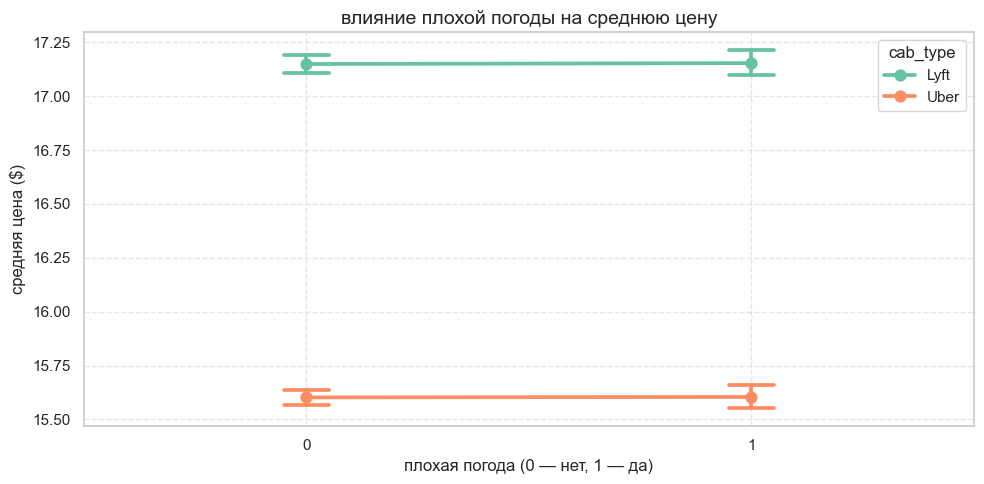

In [19]:
plt.figure(figsize=(10, 5))
sns.pointplot(x='bad_weather', y='price', hue='cab_type',
              data=df, capsize=.1, palette='Set2')
plt.title('влияние плохой погоды на среднюю цену', fontsize=14)
plt.xlabel('плохая погода (0 — нет, 1 — да)')
plt.ylabel('средняя цена ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('data/processed/weather_price.png', dpi=150)
plt.show()

# цена по времени суток

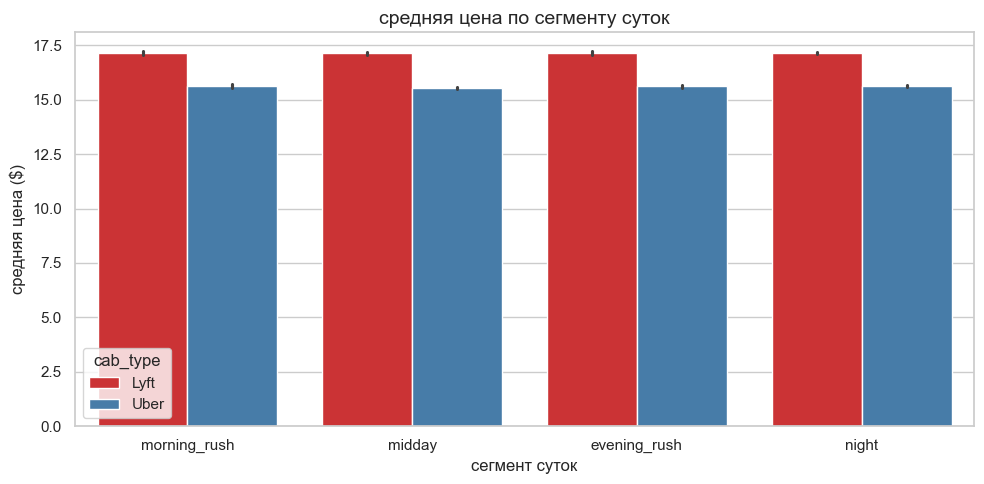

In [20]:
segment_order = ['morning_rush', 'midday', 'evening_rush', 'night']
plt.figure(figsize=(10, 5))
sns.barplot(x='time_segment', y='price', hue='cab_type',
            data=df, order=segment_order, palette='Set1',
            estimator='mean', errorbar='ci')
plt.title('средняя цена по сегменту суток', fontsize=14)
plt.xlabel('сегмент суток')
plt.ylabel('средняя цена ($)')
plt.tight_layout()
plt.savefig('data/processed/time_segment_price.png', dpi=150)
plt.show()

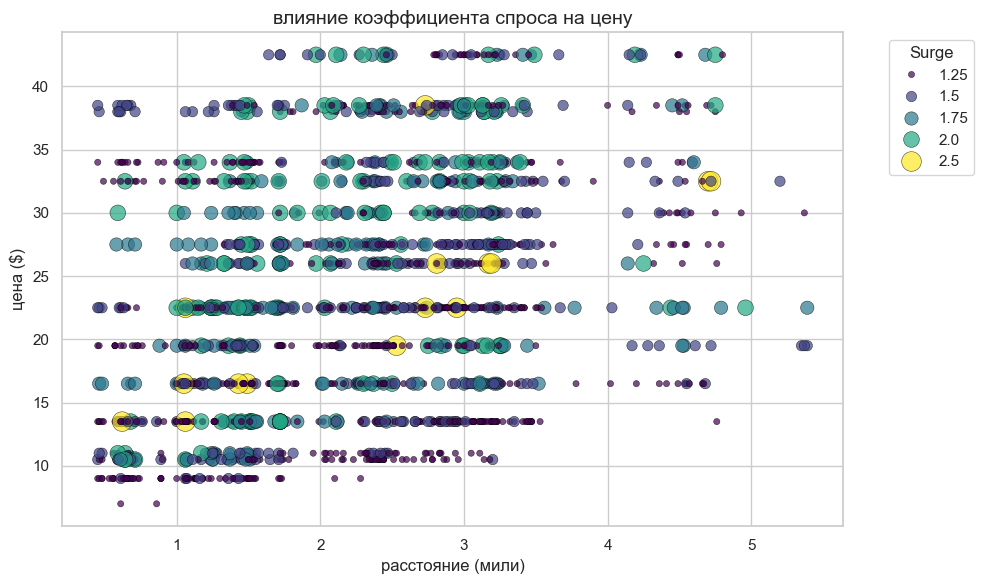

In [21]:
surge_df = df[df['surge_multiplier'] > 1].sample(
    min(2000, (df['surge_multiplier'] > 1).sum()), random_state=42
)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance', y='price', hue='surge_multiplier',
                size='surge_multiplier', sizes=(20, 200),
                data=surge_df, palette='viridis', alpha=0.7,
                edgecolor='black', linewidth=0.4)
plt.title('влияние коэффициента спроса на цену', fontsize=14)
plt.xlabel('расстояние (мили)')
plt.ylabel('цена ($)')
plt.legend(title='Surge', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('data/processed/surge_effect.png', dpi=150)
plt.show()

---
## Train / Validation / Test сплит

### 70 / 15 / 15

| Выборка | Размер | Назначение |
|---|---|---|
| **Train** | 70% | Обучение модели |
| **Validation** | 15% | Подбор гиперпараметров |
| **Test** | 15% | Финальная оценка |

### Как избежали data leakage

1. **нет признаков из будущего.** все признаки известны в момент *вызова* машины, а не после завершения поездки. `surge_multiplier` — информация, доступная пассажиру до подтверждения заказа 
2. **нормировка/энкодинг — только по train.** если на следующем шаге применяется StandardScaler или OrdinalEncoder, объект `fit` вызывается только на `X_train`, а `transform` — на val/test. 
3. **случайный сплит оправдан.** временной тренд в данных слабый. если бы модель должна была предсказывать «будущие» поездки, использовался бы `TimeSeriesSplit` 

результат воспроизводим

In [22]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train:      {len(X_train):>7,}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val):>7,}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:       {len(X_test):>7,}  ({len(X_test)/len(X)*100:.1f}%)")
print(f"Total:      {len(X):>7,}")

# проверяем, что распределение таргета похоже во всех выборках
print("\nсредняя цена:")
print(f"Train: ${y_train.mean():.2f}")
print(f"Val:   ${y_val.mean():.2f}")
print(f"Test:  ${y_test.mean():.2f}")

Train:      430,061  (70.0%)
Validation:  92,156  (15.0%)
Test:        92,156  (15.0%)
Total:      614,373

средняя цена:
Train: $16.35
Val:   $16.33
Test:  $16.36


---
## выбор метрик

предсказание числовой цены поездки

### используемые метрики

| метрика | формула | смысл |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | средняя ошибка в долларах; интерпретируемый бизнес-показатель |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | штрафует крупные ошибки сильнее; важно для дорогих поездок |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | доля объяснённой дисперсии; позволяет сравнивать модели |

### приоритет: **MAE**

- имеет прямую денежную интерпретацию: «модель ошибается в среднем на $X»
- После удаления выбросов распределение цены достаточно симметрично - MAE и RMSE дают схожую информацию, но MAE не искажается редкими крупными отклонениями

**почему не только MAE:**
- RMSE показывает, насколько «катастрофичны» худшие предсказания
- R² нужен для быстрого сравнения: «объяснили ли мы 90% дисперсии или только 70%?»

**MAPE не используем** — при дешёвых поездках (\$2–4) даже ошибка в \$1 даёт 25–50%, что сильно искажает картину

In [23]:
baseline_pred = np.full(len(y_val), y_train.mean())

mae  = mean_absolute_error(y_val, baseline_pred)
rmse = root_mean_squared_error(y_val, baseline_pred)  
r2   = r2_score(y_val, baseline_pred)

print("Baseline (predict mean):")
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²:    {r2:.4f}")

Baseline (predict mean):
MAE:  $7.23
RMSE: $8.70
R²:    -0.0000


---
## сохранение обработанных данных

In [24]:
X_train.to_csv('data/processed/X_train.csv', index=False)
X_val.to_csv('data/processed/X_val.csv',   index=False)
X_test.to_csv('data/processed/X_test.csv',  index=False)
y_train.to_csv('data/processed/y_train.csv', index=False)
y_val.to_csv('data/processed/y_val.csv',   index=False)
y_test.to_csv('data/processed/y_test.csv',  index=False)

print(f"исходных строк (cab_rides): {len(rides):,}")
print(f"после объединения с погодой: {len(df):,}")
print(f"добавлено новых фич: 6")
print(f"Train / Val / Test:  {len(X_train):,} / {len(X_val):,} / {len(X_test):,}")
print(f"метрика: MAE ($), доп: RMSE ($), R²")

исходных строк (cab_rides): 693,071
после объединения с погодой: 614,373
добавлено новых фич: 6
Train / Val / Test:  430,061 / 92,156 / 92,156
метрика: MAE ($), доп: RMSE ($), R²
